In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
url = "https://huggingface.co/datasets/yandex/yambda/resolve/main/sequential/50m/listens.parquet"
df = pd.read_parquet(url)
print(f"Загружено {len(df)} пользователей")
df.head()

Загружено 9238 пользователей


,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds
0,100,"[39420, 39420, 39625, 40110, 40360, 40380, 406...","[8326270, 1441281, 286361, 732449, 3397170, 78...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[100, 100, 100, 100, 46, 100, 100, 100, 100, 1...","[170, 105, 185, 240, 130, 205, 205, 145, 95, 2..."
1,200,"[14329075, 14329075, 14329075, 14329075, 14329...","[3285270, 5253582, 9155883, 6113313, 1142869, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[9, 28, 42, 32, 0, 0, 5, 9, 100, 100, 100, 6, ...","[170, 170, 205, 155, 215, 185, 205, 195, 165, ..."
2,300,"[54090, 54100, 54110, 54120, 54125, 54135, 541...","[618910, 8793425, 8842650, 5806319, 8495320, 9...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 4, 4, 5, 1, 5, 7, 1, 2, 2, 10, 6, 1, 23, 6...","[270, 130, 225, 210, 300, 210, 190, 340, 240, ..."
3,500,"[22695440, 22695690, 22695715, 22696095, 22696...","[6417502, 6896222, 6896938, 6950641, 7981221, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, ...","[100, 37, 10, 37, 100, 100, 11, 13, 20, 100, 1...","[225, 210, 240, 165, 150, 245, 135, 165, 275, ..."
4,600,"[1329190, 1329405, 1329690, 1329950, 1330185, ...","[8077497, 1865247, 95237, 4624864, 8332575, 44...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[100, 100, 100, 100, 100, 100, 100, 100, 100, ...","[245, 215, 235, 260, 250, 280, 180, 195, 155, ..."


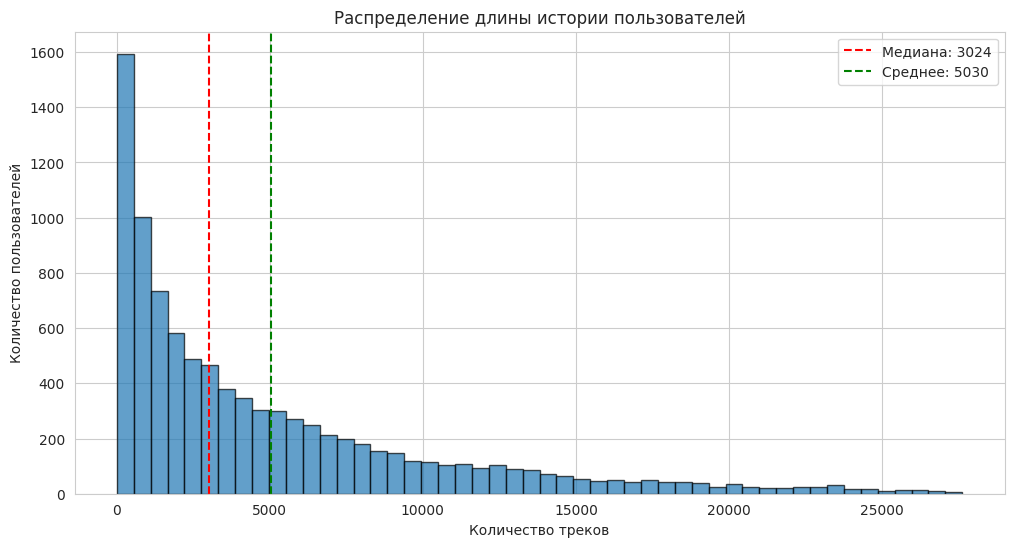

In [ ]:
df['seq_len'] = df['item_id'].apply(len)
plt.hist(df['seq_len'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение длины истории пользователей')
plt.xlabel('Количество треков')
plt.ylabel('Количество пользователей')
plt.axvline(df['seq_len'].median(), color='red', linestyle='--',
            label=f'Медиана: {df["seq_len"].median():.0f}')
plt.axvline(df['seq_len'].mean(), color='green', linestyle='--',
            label=f'Среднее: {df["seq_len"].mean():.0f}')
plt.legend()
plt.show()

In [ ]:
print(df['item_id'].iloc[0][:20])
print(f"Всего треков: {len(df['item_id'].iloc[0])}")
print(f"Уникальных треков: {len(set(df['item_id'].iloc[0]))}")

[8326270 1441281  286361  732449 3397170 7849270 1449307 6887232 2996197
 6474571 7847600 7509517  470320 6641244 2581903 5485459 5474898 3088475
 7521298 8329413]
Всего треков: 3585
Уникальных треков: 892


На основе анализа распределения длины истории пользователя,видим,что медианное значение 3 000 треков и среднее 5 000 треков на пользователя. Значительное превышение среднего над медианой указывает на наличие пользователей с аномально длинной историей (10 000+ треков). На основе предметной области (рекомендация следующего трека) и ограничений вычислительных ресурсов (self-attention имеет квадратичную сложность O(n²)) выбран параметр max_seq_len=50 для модели. Данное значение позволяет модели сфокусироваться на недавних предпочтениях пользователя, что нам важно для предсказания следующего трека, и одновременно укладывается в лимиты по времени обучения.

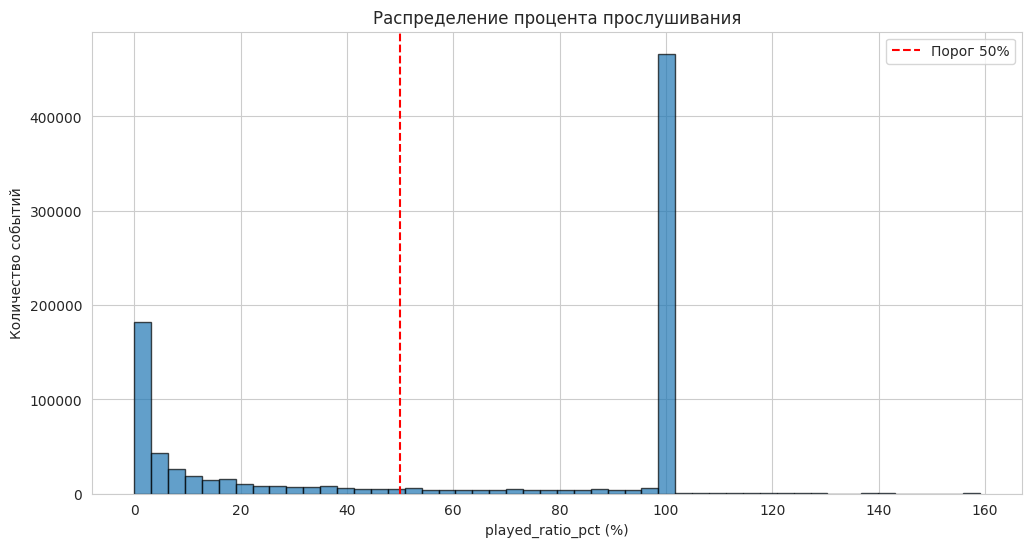

In [ ]:
all_ratios = []
for ratios in df['played_ratio_pct']:
    # Берём первые 100 значений (или меньше, если их меньше) так как все значения не влезут в память
    sample = ratios[:100] if len(ratios) > 100 else ratios
    # Убеждаемся, что это числа
    for r in sample:
        try:
            all_ratios.append(float(r))
        except:
            pass

plt.hist(all_ratios, bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение процента прослушивания')
plt.xlabel('played_ratio_pct (%)')
plt.ylabel('Количество событий')
plt.axvline(50, color='red', linestyle='--', label='Порог 50%')
plt.legend()
plt.show()

На графике прослушиваний видно бимодальное распределение: много событий, где прослушан трек был до конца (100 процентов), а также много событий скипнутых треков,которые сразу не понравились пользователю. На основе анализа выбран порог фильтрации 50 процентов для отделения треков,которые более вероятно пользователю понравились и он дослушает их до конца.

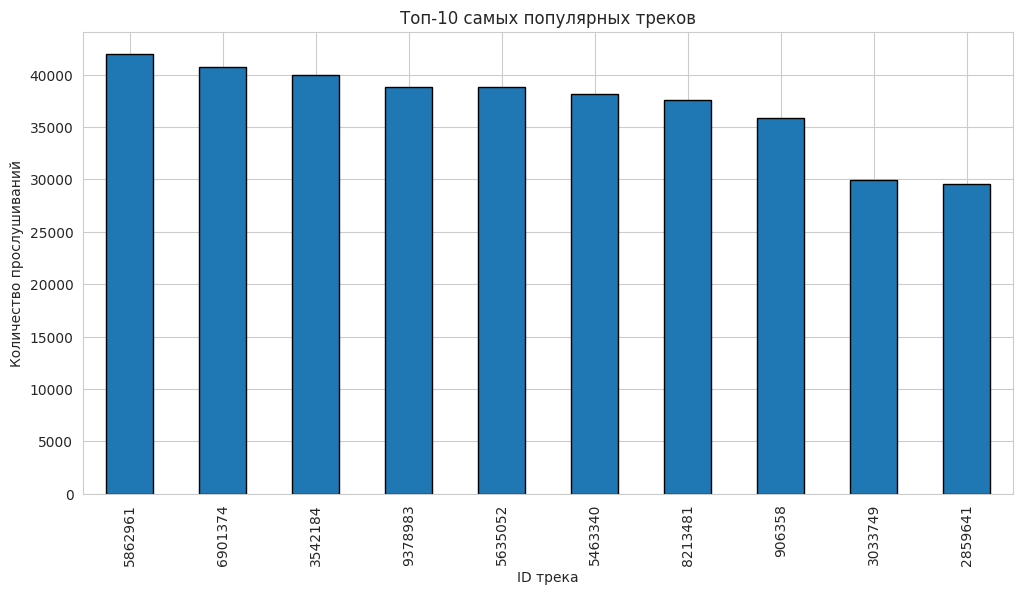

In [ ]:
all_items = []
for items in df['item_id']:
    all_items.extend(items)
top_ids = pd.Series(all_items).value_counts().head(10)
top_ids.plot(kind='bar', edgecolor='black')
plt.title('Топ 10 популярных треков')
plt.xlabel('ID трека')
plt.ylabel('Количество прослушиваний')
plt.show()

In [ ]:
print(f"Средняя длина истории: {df['seq_len'].mean():.1f}")
print(f"Медиана длины истории: {df['seq_len'].median():.0f}")
print(f"Мин - Макс длина: {df['seq_len'].min()} - {df['seq_len'].max()}")
print(f"Средний процент прослушивания: {np.mean(all_ratios):.1f}%")
print(f"Доля прослушиваний более 50%: {sum(1 for ratio in all_ratios if ratio >= 50) / len(all_ratios) * 100:.1f}%")

Средняя длина истории: 5030.0
Медиана длины истории: 3024
Мин - Макс длина: 6 - 27617
Средний процент прослушивания: 61.2%
Доля прослушиваний более 50%: 59.1%
